In [28]:
# Build a linear regression model for a real-life scenario such as Housing Price Prediction,
# Student Performance Prediction, Salary Estimation, Sales Forecasting for a Retail Store, or
# any other domain-specific application.

# 1. Import the required Python libraries
#         ↓
# 2. Load the California housing CSV dataset using Pandas
#         ↓
# 3. Check the dataset shape and view the first few rows
#         ↓
# 4. Check for missing values using isnull()
#         ↓
# 5. Replace missing total_bedrooms values with its median
#         ↓
# 6. Plot a histogram to understand the distribution of house prices
#         ↓
# 7. Remove ocean_proximity temporarily and create a correlation heatmap
#         ↓
# 8. Convert ocean_proximity from text categories into 0/1 columns using one-hot encoding
#         ↓
# 9. Separate the dataset into X = features and y = target (median_house_value)
#         ↓
# 10. Split X and y into 80% training data and 20% testing data
#         ↓
# 11. Create a Linear Regression model
#         ↓
# 12. Train the model using X_train and y_train
#         ↓
# 13. Give X_test to the trained model to generate predicted prices
#         ↓
# 14. Compare some actual prices with the predicted prices
#         ↓
# 15. Calculate R², RMSE, and MAE to evaluate the model
#         ↓
# 16. Plot Actual Price vs Predicted Price to visually check the predictions
#         ↓
# 17. Optionally inspect the model's coefficients to understand its learned relationships


In [29]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score , mean_absolute_error , mean_squared_error

sns.set_style("whitegrid")

In [30]:
df=pd.read_csv("data/california housing dataset.csv")

print("shape(rows , column)",df.shape)
df.head()

shape(rows , column) (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [31]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [32]:
#handle missing value , fill total_bedroom column with median of that column
df["total_bedrooms"]=df["total_bedrooms"].fillna(df["total_bedrooms"].median())
df.isnull().sum().sum()

np.int64(0)

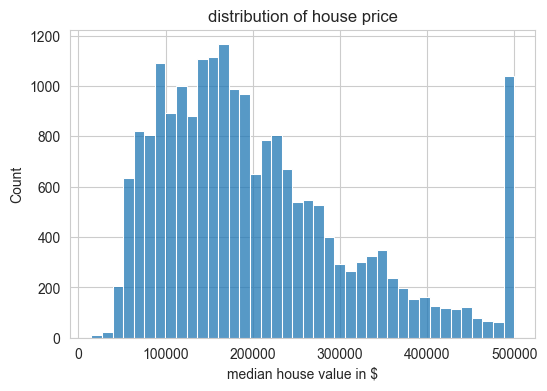

In [33]:
plt.figure(figsize=(6,4))
sns.histplot(df["median_house_value"],bins=40)
plt.title("distribution of house price")
plt.xlabel("median house value in $")
plt.show()

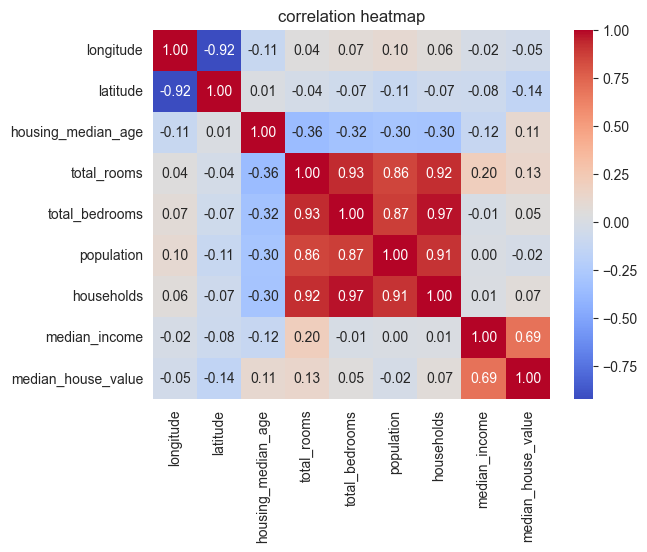

In [34]:
#to understand how numerical columns are associated with each other , we visualize a corelation matrix
numeric_df=df.drop(columns=["ocean_proximity"])#ocean_proximity is textual column hence we work on it later and for now compare only numerical data
plt.Figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(),annot=True,fmt=".2f",cmap="coolwarm")
plt.title("correlation heatmap")
plt.show()

In [35]:
#now we convert ocean_proximity column to categoral numerical value so machine understands it better 
# we call it one hot encoding 
df=pd.get_dummies(df,columns=["ocean_proximity"],drop_first=True)
df.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False


In [36]:
#split feature x and target y
X=df.drop(columns=["median_house_value"])
y=df["median_house_value"]#our target is median house val hence we remove that column

#data is split as 20%test and 80% train
X_train, X_test , y_train, y_test =train_test_split(X,y,test_size=0.2,random_state=42)

print("no of training samples : ",X_train.shape[0])
print("no of test samples : ",X_test.shape[0])

no of training samples :  16512
no of test samples :  4128


In [37]:
#traing linear regression model
model=LinearRegression()
model.fit(X_train,y_train)
print("model trained successfully!!!")

model trained successfully!!!


In [38]:
y_pred=model.predict(X_test)#give x test data to y to predict the unseeen data

comparison=pd.DataFrame({"actual":y_test.values[:10]," predicted : ":y_pred[:10].round(0)})
comparison

,actual,predicted :
0,47700.0,54055.0
1,45800.0,124225.0
2,500001.0,255489.0
3,218600.0,268002.0
4,278000.0,262769.0
5,158700.0,139606.0
6,198200.0,290665.0
7,157500.0,228265.0
8,340000.0,256507.0
9,446600.0,407924.0


In [39]:
r2=r2_score(y_test,y_pred) # the mrore its close to 1 the more its good for us else we doomed fr
rmse=mean_squared_error(y_test, y_pred)**0.5 #here ** is exponent
mae=mean_absolute_error(y_test,y_pred)

print(f"R2 Score : {r2:.3f}  -> model explains {r2*100:.1f}% of the price variation")
print(f"RMSE     : ${rmse:,.0f}")
print(f"MAE      : ${mae:,.0f}")

R2 Score : 0.625  -> model explains 62.5% of the price variation
RMSE     : $70,061
MAE      : $50,671


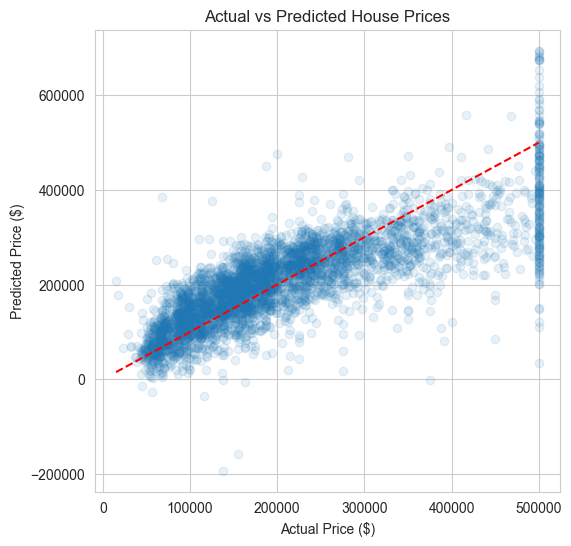

In [40]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred,alpha=0.1)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color="red", linestyle="--")
plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.title("Actual vs Predicted House Prices")
plt.show()